<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Chapter4_Linear_Discriminant_Analysis_with_Handwritten_Recognition_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***This example demonstrates the impelmentation of Fisher's linear discriminant analysis ***
1. How to manually implement Fisher's linear discriminant analysis
2. How to use existing package (shortcut)

# **First, Load digit handwritten data**

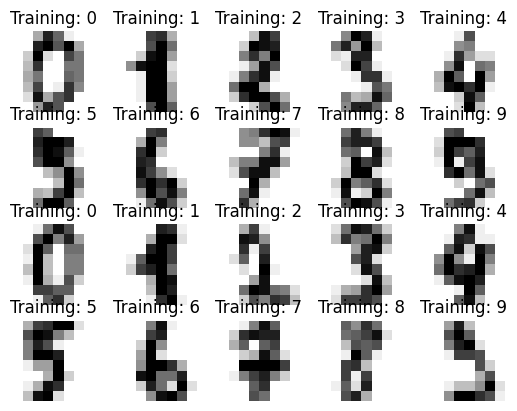

In [1]:
# Standard scientific Python imports
import matplotlib.pyplot as plt

from sklearn import datasets, svm, metrics

# The digits dataset
digits = datasets.load_digits()

# The data that we are interested in is made of 8x8 images of digits, let's
# have a look at the first 4 images, stored in the `images` attribute of the
# dataset. If we were working from image files, we could load them using
# matplotlib.pyplot.imread. Note that each image must have the same size. For these
# images, we know which digit they represent: it is given in the 'target' of
# the dataset.

images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:20]):
    plt.subplot(4, 5, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)

# **Manual implementation of LDA on Slides 18-19 of Chapter 4**
Note: You can only classify two classes at a time by following the formula

Training accuracy:
Test accuracy:


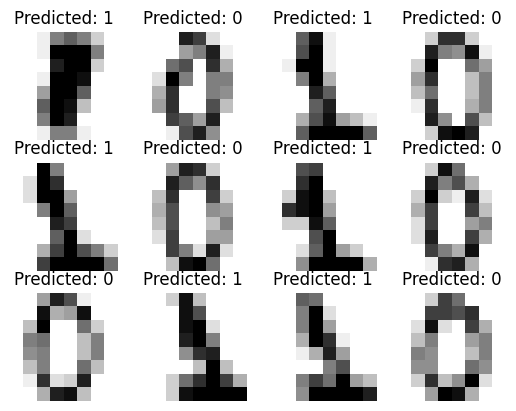

In [4]:
import numpy as np

# Consider only two classes, say, 0 and 1
# introduce a mask technique to screen 0 and 1 only
mask = (digits.target==0)| (digits.target==1) # mask generates true or false. If the label is 0 or 1, it is true, if it is others, false
# Use false to prevent the related data from being loaded. X has 360X64
X = digits.images[mask].reshape(-1,64)
y = digits.target[mask] #size (360,)

# Split data in half: train and test
n_samples = len(y) # Find out 360 data for 0 and 1 images

X_train = X[:n_samples //2] # First half of data as training. Size is 180X64
y_train = y[:n_samples //2] # Size 180,
X_test = X[n_samples //2:] # second half of data as testing. Size 180X64
y_test = y[n_samples //2:]  # size 180,

# Step 1: Compute the sample means for each class
m_x1 =  np.mean(X_train[y_train==0], axis=0)# size 64,
m_x2 =  np.mean(X_train[y_train==1], axis=0)# size 64,
# X_train[y_train ==0] has 64 columns

# Step 2: Compute the within-class scatter matrix; slide # 18

s1 = sum([(x-m_x1).reshape(64, 1)@(x-m_x1).reshape(1, 64) for x in X_train[y_train ==0]])

s2 = sum([(x-m_x2).reshape(64, 1)@(x-m_x2).reshape(1, 64)  for x in X_train[y_train==1]])
S = s1 + s2

# If data are not enough, we may encounter singularity problem.
# Adding a little bit regularization may help
reg_term = 1e-5*np.eye(S.shape[0])
S_regularized = S + reg_term

# Step 3: Compute omega_F
omega_F = np.linalg.inv(S_regularized).dot(m_x2-m_x1)
omega_F = omega_F/np.linalg.norm(omega_F)   # Normalize. Size of omega_F is ...

# Compute omega_o
omega_o = -0.5*(m_x1@omega_F+m_x2.dot(omega_F))

# Project training and test data
X_train_projected = X_train.dot(omega_F)
X_test_projected = X_test.dot(omega_F)

# Classify based on the projection
y_train_pred = (X_train_projected>omega_o).astype(int)
y_test_pred = (X_test_projected>omega_o).astype(int)

# Output some results
print("Training accuracy:",)
print("Test accuracy:",  )


images_and_labels = list(zip(X_test, y_test_pred)) # create a list of tuples X vs. labels
for index, (image, label) in enumerate(images_and_labels[:12]):
    plt.subplot(3, 4, index + 1)
    plt.axis('off')
    image2 = image.reshape(8, 8)
    plt.imshow(image2, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Predicted: %i' % label)


plt.show()

# **Shortcut: Using existing library to perform LDA**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

# To apply a classifier on this data, we need to flatten each 8 x 8 image to a 64 dimensional feature vector
n_samples = len(digits.images)
X = digits.images.reshape((n_samples, -1)) #LDA cannot handle 2D data directly, we flatten each 8x8 image into a 64-element
y = digits.target

# We learn the digits on the first half of the digits
# Define classifer fit data to first half of samples
# solver lsqr is used. It is not least square estimation sensitive to outliers as discussed in the slides
# lsqr is the least square approach to obtain hyperplane by maximizing between-class difference while minimizing
# within-class variance in Fisher’s Discrimiant Analysis
# auto shrinkage can help when the number of features exceeds the number of samples
# Fit a model to the first half of data in X and y
clf1 =
# Now predict the value of the digit on the second half:

predicted =

images_and_labels = list(zip(X[n_samples // 2:], predicted)) # create a list of tuples X vs. labels
for index, (image, label) in enumerate(images_and_labels[:12]):
    plt.subplot(3, 4, index + 1)
    plt.axis('off')
    image2 = image.reshape(8, 8)
    plt.imshow(image2, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Predicted: %i' % label)


plt.show()

Error = 2 * np.sum(y_test != predicted) / n_samples
print('Prediction Error Rate: %f' % Error)

# **Exercise: Please use the coding template above to recognize more than 0 and 1, i.e., recognizing 0-9.**